In [ ]:
import sys
import pandas as pd
import seaborn 
!uv pip install scipy --python {sys.executable}
from scipy import stats

Resolved 2 packages in 44.38s                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/33.60 MiB           
⠙ Preparing packages... (0/1)------------------- 14.00 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 30.00 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 45.58 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 61.58 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 62.00 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 78.00 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 94.00 KiB/33.60 MiB         
⠙ Preparing packages... (0/1)------------------- 110.00 KiB/33.60 MiB        
⠙ Preparing packages... (0/1)------------------- 126.00 KiB/33.60 MiB        
⠙ Preparing packages... (0/1)------------------- 142.00 KiB/33.60 MiB

In [ ]:
immunizations = pd.read_csv('immunizations.csv')

In [8]:
immunizations

,School,City,Adequately immunized %,Exempt %,District/LEA,Address,Zip,Map,school_type
0,river rock school,lehi,89.7,10.3,Alpine District,520 North 1700 West,84043.0,"geo:40.3937097,-111.8764976",Private
1,springside school,saratoga springs,82.9,13.7,Alpine District,694 South Highpoint Drive,84045.0,"geo:40.3494704,-111.9152738",Private
2,american preparatory academy accelerated school,west valley city,94.2,3.5,NaN,NaN,NaN,NaN,Public
3,american preparatory academy,draper,92.0,7.0,American Preparatory Academy,12892 S PONY EXPRESS RD,84020.0,"geo:40.517489,-111.891825",Public Charter
4,american preparatory academy salem,salem,74.6,25.4,NaN,NaN,NaN,NaN,Public
...,...,...,...,...,...,...,...,...,...
629,island view school,west point,91.0,7.2,NaN,NaN,NaN,NaN,Public
630,utah peak academy,junction,50.0,45.0,Piute District,PO Box 69,84740.0,"geo:38.245546,-112.221783",Private
631,wallace stegner academy kearns,west valley city,95.9,4.1,NaN,NaN,NaN,NaN,Public
632,haven bay,west haven,89.8,8.5,NaN,NaN,NaN,NaN,Public


<Axes: xlabel='school_type', ylabel='Adequately immunized %'>

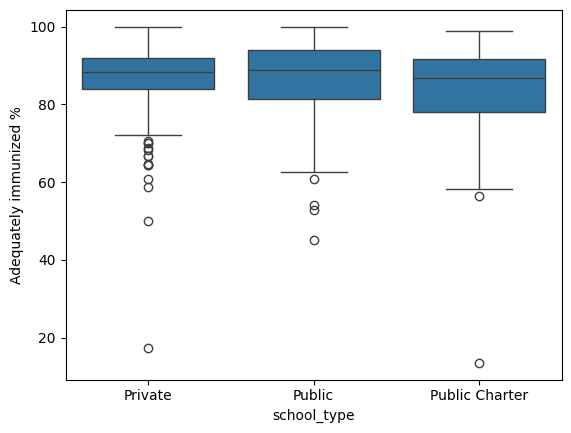

In [ ]:
seaborn.boxplot(data=immunizations, x='school_type', y='Adequately immunized %')
# or violin for more distributional detail
# sns.violinplot(data=immunizations, x='school_type', y='Adequately immunized %')

<Axes: xlabel='Adequately immunized %', ylabel='Count'>

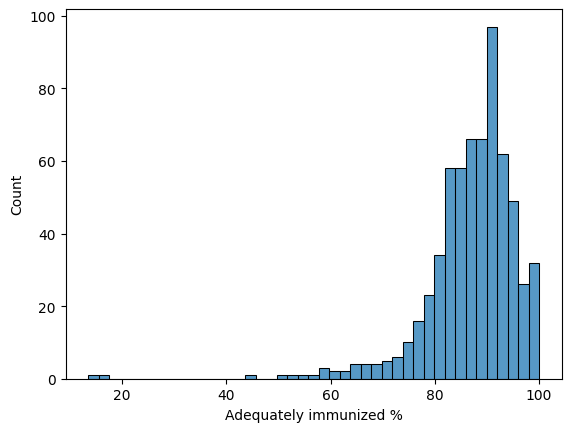

In [9]:
seaborn.histplot(data = immunizations, x = 'Adequately immunized %')

In [20]:
charter_priv = immunizations[immunizations['school_type'].isin(['Charter', 'Private'])]['Adequately immunized %']
# private = immunizations[immunizations['school_type'] == 'Private']['Adequately immunized %']
public = immunizations[immunizations['school_type'] == 'Public']['Adequately immunized %']
immunizations['non_trad'] = immunizations['school_type'].isin(['Charter', 'Private']).astype(int)


<Axes: xlabel='non_trad', ylabel='Adequately immunized %'>

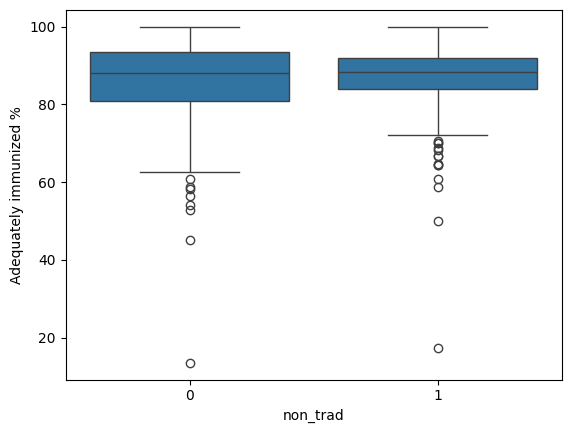

In [ ]:
seaborn.boxplot(data = immunizations, x = 'non_trad', y = 'Adequately immunized %')

/tmp/ipykernel_14707/89534354.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public School', 'Private or Charter School'])


Text(0.5, 0, '')

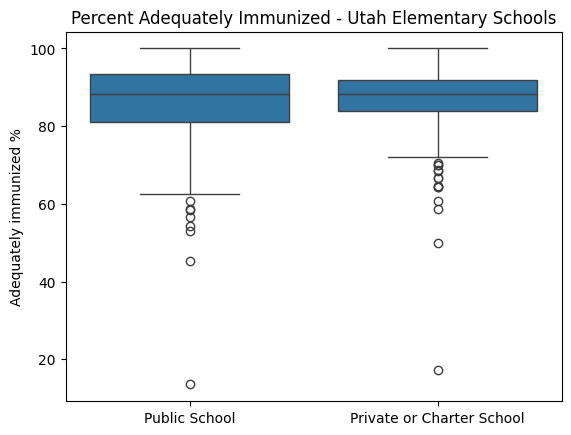

In [28]:
ax = seaborn.boxplot(data=immunizations, x='non_trad', y='Adequately immunized %')

ax.set_xticklabels(['Public School', 'Private or Charter School'])
ax.set_title('Percent Adequately Immunized - Utah Elementary Schools')
ax.set_xlabel('')

/tmp/ipykernel_14707/999292610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)
/tmp/ipykernel_14707/999292610.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public School', 'Private or Charter School'])


Text(0.5, 0, '')

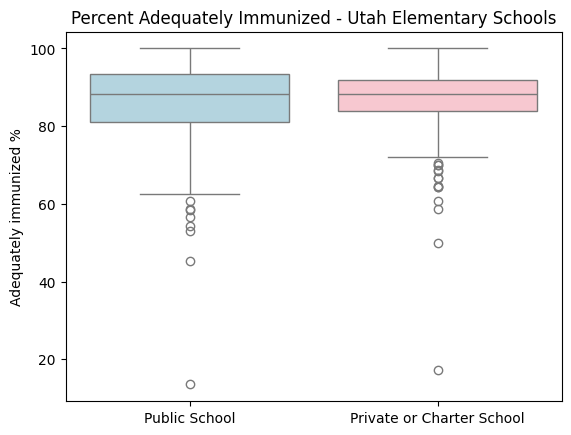

In [34]:
ax = seaborn.boxplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)

ax.set_xticklabels(['Public School', 'Private or Charter School'])
ax.set_title('Percent Adequately Immunized - Utah Elementary Schools')
ax.set_xlabel('')

/tmp/ipykernel_14707/638756077.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.violinplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)
/tmp/ipykernel_14707/638756077.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Public School', 'Private or Charter School'])


Text(0.5, 0, '')

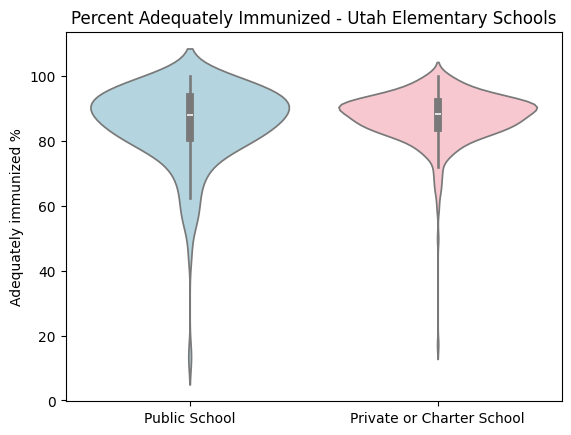

In [33]:
ax = seaborn.violinplot(data=immunizations, x='non_trad', y='Adequately immunized %', palette=['lightblue', 'pink'],)

ax.set_xticklabels(['Public School', 'Private or Charter School'])
ax.set_title('Percent Adequately Immunized - Utah Elementary Schools')
ax.set_xlabel('')

In [ ]:
statistic, p_value = stats.shapiro(public)

print(f"Shapiro-Wilk Statistic: {statistic}")
print(f"P-value: {p_value}")

# wow these are really low. guess i can't do a t-test 

Shapiro-Wilk Statistic: 0.9010716527402098
P-value: 3.2583564878195996e-07


In [25]:
print('nontrad variance', charter_priv.var(), 'public school variance', public.var())

nontrad variance 56.634707244671944 public school variance 105.69876161919039


In [ ]:
stat, p_val = stats.levene(charter_priv, public)
print(f"Levene's P-value: {p_val}") 

Levene's P-value: 0.00011776378550947484
